<a href="https://colab.research.google.com/github/Rishav-134/Matchine-learning/blob/main/Carprice_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files

uploaded = files.upload()

Saving ford.csv to ford.csv


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [6]:
df=pd.read_csv("ford.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [17]:
df.shape








,count
model,
Fiesta,6557
Focus,4588
Kuga,2225
EcoSport,1143
C-MAX,543
Ka+,531
Mondeo,526
B-MAX,355
S-MAX,296


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [ ]:
df.describe()
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [18]:
df.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


In [22]:

df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

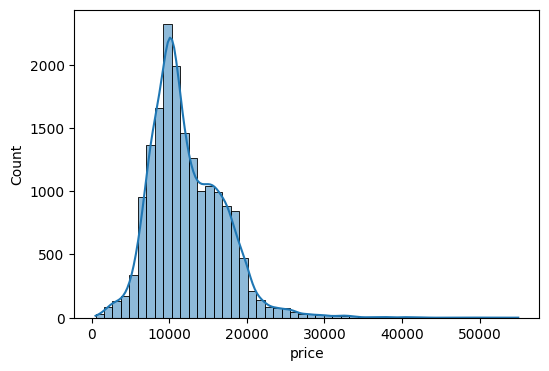

In [23]:
plt.figure(figsize=(6,4))
sns.histplot(df['price'],bins=50,kde=True)
plt.show()


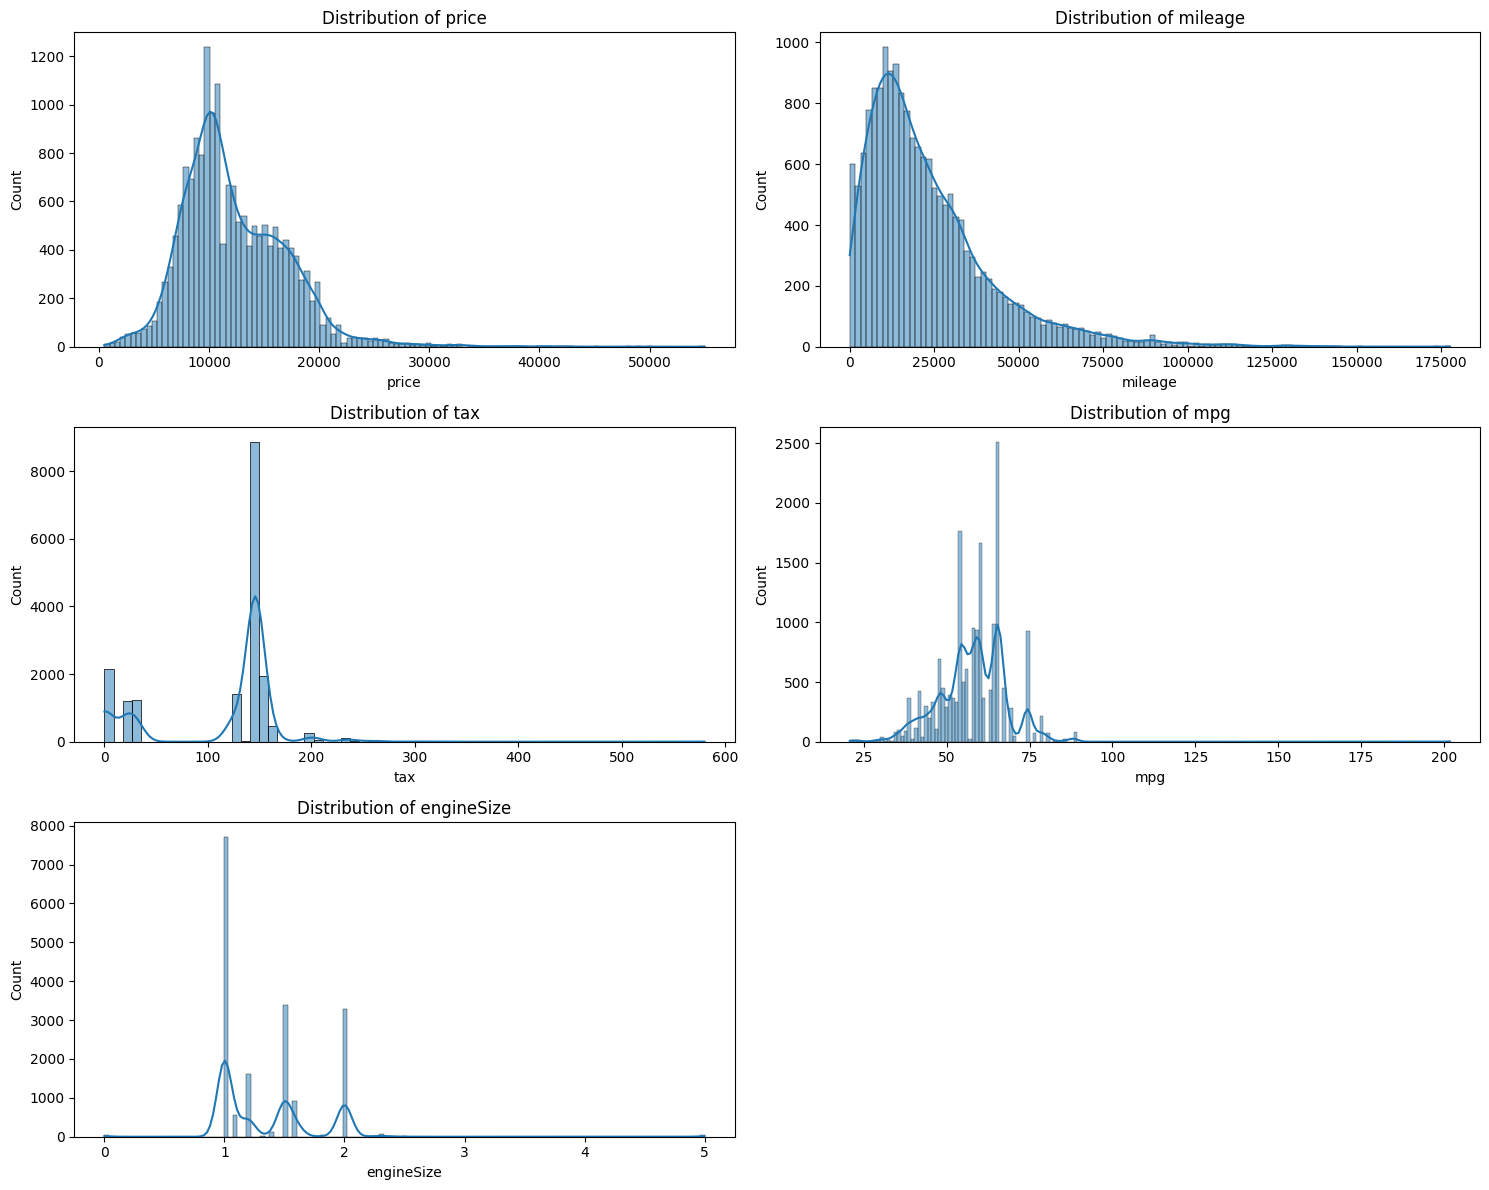

In [30]:
plt.figure(figsize=(15, 12)) # Create a figure to hold multiple subplots

def plot(var,num):
  plt.subplot(3, 2, num) # Create a 3x2 grid, and position the plot at 'num'
  sns.histplot(df[var], kde=True) # Re-added histplot to actually draw the distribution
  plt.title(f'Distribution of {var}') # Add a title for each subplot

plot("price",1)
plot("mileage",2)
plot("tax",3)
plot("mpg",4)
plot("engineSize",5)

plt.tight_layout() # Adjust subplot params for a tight layout
plt.show() # Display the figure

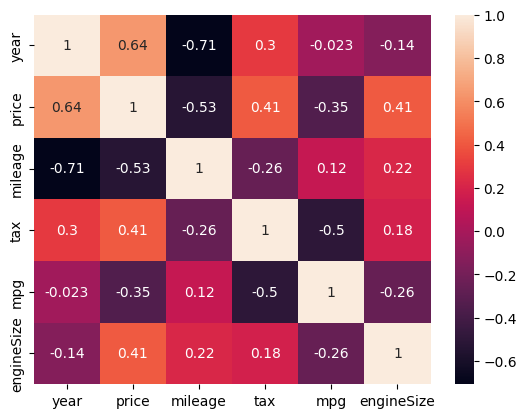

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

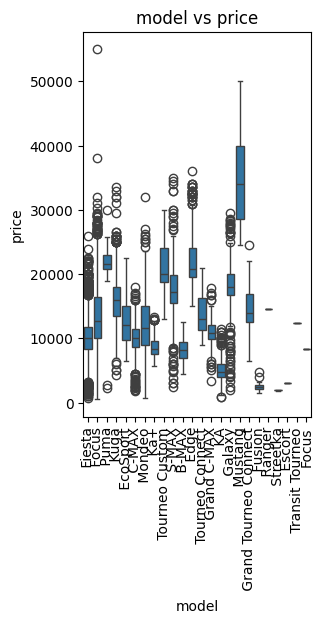

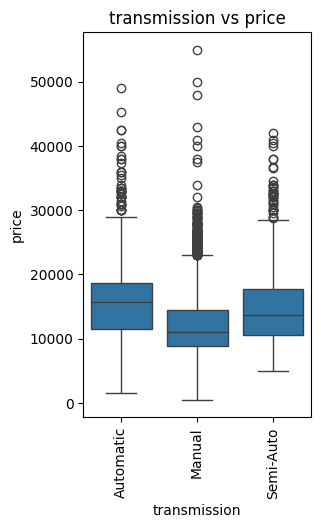

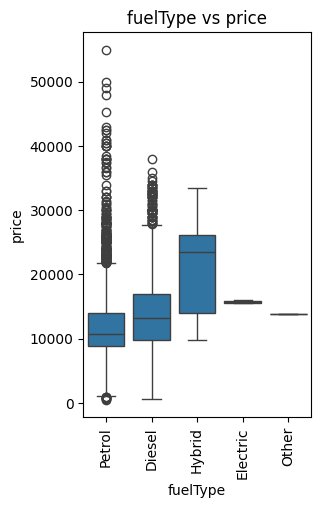

In [44]:
def box_plot(var1,var2,num,data=df):
  plt.figure(figsize=(10,5))
  plt.subplot(1,3,num)
  sns.boxplot(x=var1,y=var2,data=df)
  plt.xticks(rotation=90)
  plt.title(f"{var1} vs {var2}")
  plt.show()

box_plot("model","price",1)
box_plot("transmission","price",2)
box_plot("fuelType","price",3)



In [56]:
import pandas as pd

# Check if df is None due to previous errors; if so, re-initialize it.
# This assumes 'df' should be the DataFrame loaded from 'ford.csv'.
if df is None:
    print("DataFrame 'df' is None, re-loading from 'ford.csv' to proceed.")
    df = pd.read_csv("ford.csv")

# Now attempt to drop columns, handling cases where they might not exist
df = df.drop(columns=["mileage_sqrt","mileage_cbrt",'mileage_log'],axis=1, errors='ignore')
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [57]:
X=df.drop(columns=["price"],axis=1)
Y=df["price"]


In [92]:
Xlebel=pd.get_dummies(X,columns=["model","transmission","fuelType"],drop_first=True)
Xlebel=Xlebel.astype(int)
Xlebel.head()

,year,mileage,tax,mpg,engineSize,model_1,model_2,model_3,model_4,model_5,...,model_20,model_21,model_22,model_23,transmission_1,transmission_2,fuelType_1,fuelType_2,fuelType_3,fuelType_4
0,2017,15944,150,57,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,12456,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,10460,145,40,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,2019,1482,145,48,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


In [94]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler=StandardScaler()
X_scaled_array = scaler.fit_transform(Xlebel)
# Convert the scaled array back to a DataFrame, preserving column names
X_scaled = pd.DataFrame(X_scaled_array, columns=Xlebel.columns)
X_scaled.head()

,year,mileage,tax,mpg,engineSize,model_1,model_2,model_3,model_4,model_5,...,model_20,model_21,model_22,model_23,transmission_1,transmission_2,fuelType_1,fuelType_2,fuelType_3,fuelType_4
0,0.065128,-0.380998,0.591358,-0.042122,-0.447984,-0.176538,-0.260658,-0.108227,-0.007461,1.319080,...,-0.042897,-0.062092,-0.007461,-0.007461,-2.517747,-0.253771,-0.010551,-0.035015,-0.007461,0.68932
1,0.552866,-0.733359,0.591358,-0.042122,-0.447984,-0.176538,-0.260658,-0.108227,-0.007461,-0.758104,...,-0.042897,-0.062092,-0.007461,-0.007461,0.397180,-0.253771,-0.010551,-0.035015,-0.007461,0.68932
2,0.065128,-0.560132,0.591358,-0.042122,-0.447984,-0.176538,-0.260658,-0.108227,-0.007461,-0.758104,...,-0.042897,-0.062092,-0.007461,-0.007461,0.397180,-0.253771,-0.010551,-0.035015,-0.007461,0.68932
3,1.040605,-0.662640,0.510727,-1.721198,-0.447984,-0.176538,-0.260658,-0.108227,-0.007461,1.319080,...,-0.042897,-0.062092,-0.007461,-0.007461,0.397180,-0.253771,-0.010551,-0.035015,-0.007461,0.68932
4,1.040605,-1.123724,0.510727,-0.931045,-0.447984,-0.176538,-0.260658,-0.108227,-0.007461,1.319080,...,-0.042897,-0.062092,-0.007461,-0.007461,-2.517747,-0.253771,-0.010551,-0.035015,-0.007461,0.68932


In [95]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [96]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.33, random_state=42)

In [97]:
model=LinearRegression()
model.fit(X_train,y_train)


LinearRegression()

In [99]:
y_pred=model.predict(X_test)
y_pred

array([ 6888.75487917,  9328.62297666,  9420.53085767, ...,
       19099.96373064,  4948.44438264, 10424.59544226])

In [100]:
y_test

,price
17610,6995
7076,8999
1713,7998
1611,5491
16830,3790
...,...
6015,19000
10301,10940
15006,21999
5396,6995


In [101]:
r2=r2_score(y_test,y_pred)
r2

0.8396626991294073

In [102]:
n = X_test.shape[0]
k = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
print(f"Adjusted R-squared: {adjusted_r2}")

Adjusted R-squared: 0.8387377808685318
